<a href="https://colab.research.google.com/github/sonjeyun/ia-codyssey/blob/main/%EC%82%AC%EA%B3%84%EC%A0%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [5]:
import pandas as pd

# 파일 읽기 (파일명 정확히!)
df = pd.read_csv('/content/sample_data/ta_20260909130032.csv',
                 encoding='cp949',
                 skiprows=6)

# 컬럼 이름 정리
df.columns = ['월', '지점', '평균기온', '최저기온', '최고기온']

# 날짜 변환 + 파생변수 생성
df['월'] = df['월'].astype(str).str.strip()
df['월'] = pd.to_datetime(df['월'], format='%Y-%m')
df['연도'] = df['월'].dt.year
df['월숫자'] = df['월'].dt.month
df['일교차'] = df['최고기온'] - df['최저기온']

# 결과 확인
print(df.head())
print(f"\n총 데이터: {len(df)}개")
print(f"결측치:\n{df.isnull().sum()}")

           월   지점  평균기온  최저기온  최고기온    연도  월숫자  일교차
0 2010-01-01  108  -4.5  -8.1  -0.7  2010    1  7.4
1 2010-02-01  108   1.4  -1.7   4.9  2010    2  6.6
2 2010-03-01  108   4.3   0.5   8.1  2010    3  7.6
3 2010-04-01  108   9.5   5.6  14.0  2010    4  8.4
4 2010-05-01  108  17.2  13.0  22.0  2010    5  9.0

총 데이터: 136개
결측치:
월       0
지점      0
평균기온    0
최저기온    0
최고기온    0
연도      0
월숫자     0
일교차     0
dtype: int64


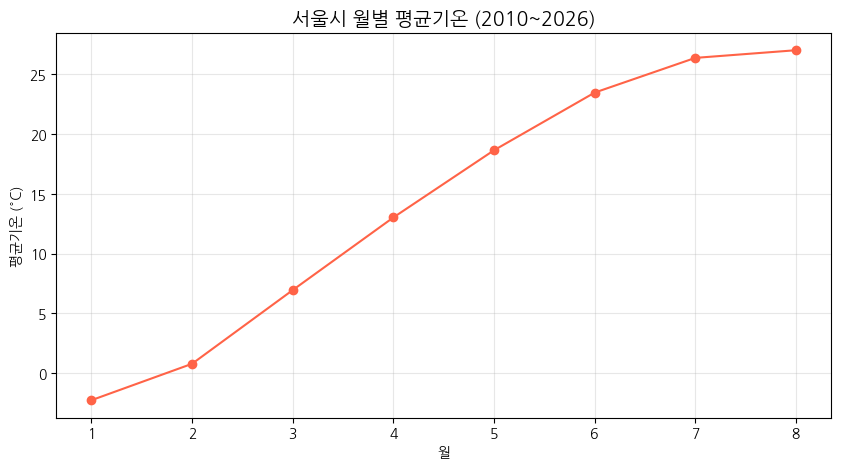

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설치 & 설정 (코랩용)
!apt-get -qq install fonts-nanum
fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)   # 마이너스 깨짐 방지

# 월별 평균기온 계산
monthly = df.groupby('월숫자')['평균기온'].mean()

# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='tomato')
plt.title('서울시 월별 평균기온 (2010~2026)', fontsize=14)
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 9))
plt.show()

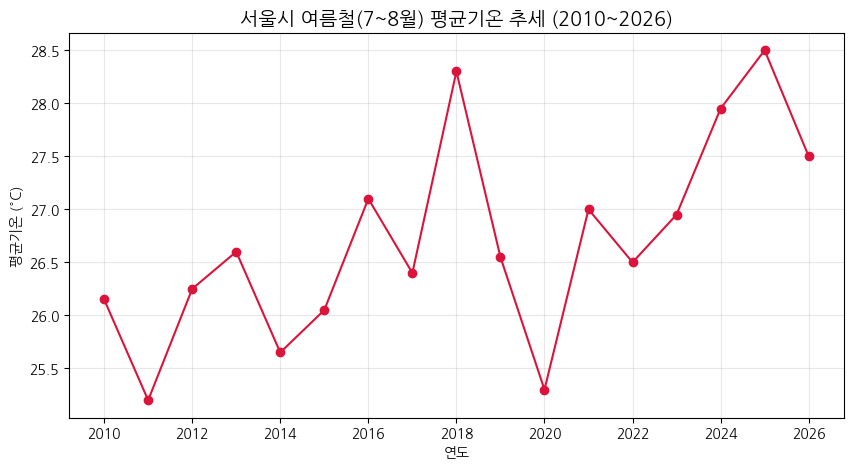

In [7]:
# 여름(7~8월)만 뽑아서, 연도별 평균기온
summer = df[df['월숫자'].isin([7, 8])].groupby('연도')['평균기온'].mean()

plt.figure(figsize=(10, 5))
plt.plot(summer.index, summer.values, marker='o', color='crimson')
plt.title('서울시 여름철(7~8월) 평균기온 추세 (2010~2026)', fontsize=14)
plt.xlabel('연도')
plt.ylabel('평균기온 (°C)')
plt.grid(True, alpha=0.3)
plt.show()

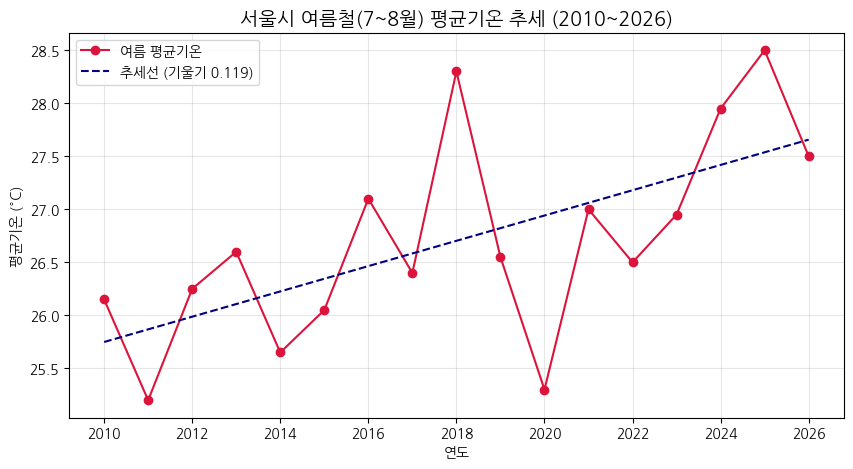

연평균 상승률: 0.119°C/년
17년간 총 상승: 약 1.91°C


In [8]:
import numpy as np

# 추세선 계산 (1차 직선으로 근사)
x = summer.index.values
y = summer.values
z = np.polyfit(x, y, 1)      # 기울기, 절편 구하기
p = np.poly1d(z)             # 직선 함수 만들기

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o', color='crimson', label='여름 평균기온')
plt.plot(x, p(x), '--', color='navy', label=f'추세선 (기울기 {z[0]:.3f})')
plt.title('서울시 여름철(7~8월) 평균기온 추세 (2010~2026)', fontsize=14)
plt.xlabel('연도'); plt.ylabel('평균기온 (°C)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"연평균 상승률: {z[0]:.3f}°C/년")
print(f"17년간 총 상승: 약 {z[0]*16:.2f}°C")

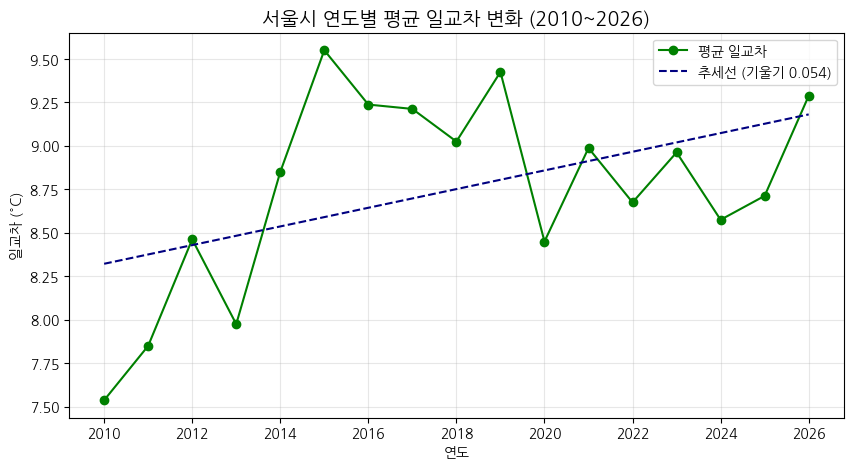

일교차 연평균 변화: 0.054°C/년


In [9]:
# 연도별 평균 일교차
diff = df.groupby('연도')['일교차'].mean()

# 추세선까지 한 번에
x = diff.index.values
y = diff.values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o', color='green', label='평균 일교차')
plt.plot(x, p(x), '--', color='navy', label=f'추세선 (기울기 {z[0]:.3f})')
plt.title('서울시 연도별 평균 일교차 변화 (2010~2026)', fontsize=14)
plt.xlabel('연도'); plt.ylabel('일교차 (°C)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"일교차 연평균 변화: {z[0]:.3f}°C/년")

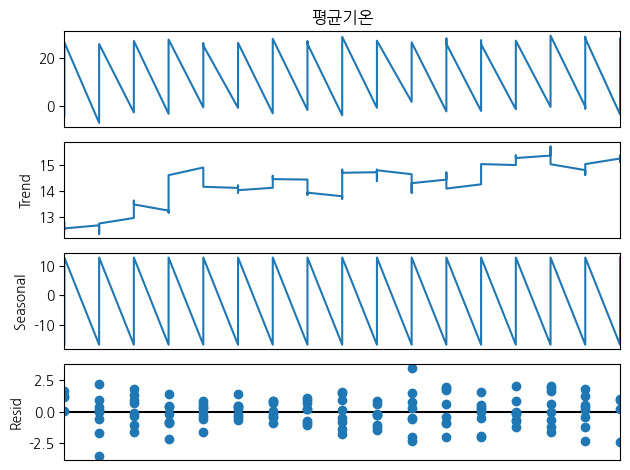

In [19]:
ts = df.set_index(pd.to_datetime(df['연도']))['평균기온']
ts = ts.sort_index()

result = seasonal_decompose(ts, model='additive', period=8)
result.plot()
plt.tight_layout()
plt.show()